<a href="https://colab.research.google.com/github/RaniaBakr/Task2_Neural/blob/main/neural_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 535s 673ms/step - accuracy: 0.3190 - loss: 2.3856 - val_accuracy: 0.5029 - val_loss: 1.5967
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 557s 668ms/step - accuracy: 0.5207 - loss: 1.5326 - val_accuracy: 0.4826 - val_loss: 1.7846
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 525s 671ms/step - accuracy: 0.5938 - loss: 1.3016 - val_accuracy: 0.6773 - val_loss: 1.0748
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 508s 650ms/step - accuracy: 0.6405 - loss: 1.1482 - val_accuracy: 0.7000 - val_loss: 1.0294
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 512s 654ms/step - accuracy: 0.6657 - loss: 1.0762 - val_accuracy: 0.7001 - val_loss: 1.0032
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 526s 673ms/step - accuracy: 0.6918 - loss: 1.0134 - val_accuracy: 0.7339 - val_loss: 0.9362
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 528s 675ms/step - accuracy: 0.7095 - loss: 0.9758 - val_accuracy: 0.7355 - val_loss: 0.9125
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 539s 645ms/step - accuracy: 0.7220 - loss: 0.94

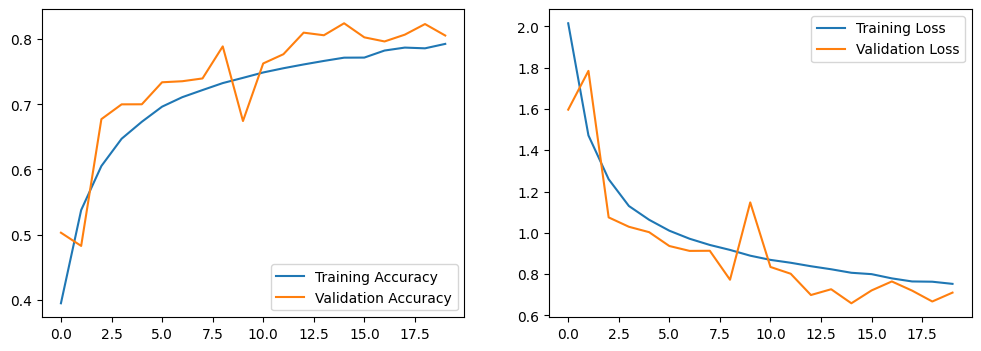

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()